### Auto ML parameter tuning example

Hyper-parameter tuning is often the most tedious part of building a machine learning model. Here I will show an example of how to use the `flaml` package to automatically tune a good machine learning model. How it works is that a default hyperparameter space has been defined, and the package will be able to search through space and find the best combination that gives the best model. It can also find the best model among some candidate models.

We will use the same housing dataset as an example.

### Installation

In [1]:
#pip install flaml

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Data

In [3]:
houses = pd.read_csv("https://raw.githubusercontent.com/Ziqi-Li/GIS5122/spring-25/data/seattle_sample_1k.csv")

In [4]:
houses.head()

,Unnamed: 0,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y,log_price
0,0,3.00,2660,4600,8,3,0,0,109,552217.557035,5.274945e+06,6.091315
1,1,2.25,2530,8736,7,4,0,0,57,565692.484331,5.272758e+06,5.790988
2,2,2.00,1390,13464,7,4,0,0,28,562451.661509,5.245291e+06,5.315130
3,3,1.00,940,4264,7,5,0,0,66,546816.935618,5.264407e+06,5.619093
4,4,2.25,2070,7225,8,3,0,0,36,564343.195352,5.244978e+06,5.477121


In [5]:
y = houses.log_price

X = houses[['bathrooms', 'sqft_living', 'sqft_lot', 'grade',
       'condition', 'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y']]

We can split the data into training (80%) and testing (20%). The model will be trained based on the training data and the testing data will be used to evaluate the model accuracy on unseen data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Modelling

For a complete list of models supported, see this link:

https://github.com/microsoft/FLAML


FLAML supports several popular and basic tree models such as


### Auto ML

In [7]:
model_list = ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost']

Settings can be speficied such as time budget, cross validation details, etc.

In [8]:
from flaml import AutoML

model_list = ['lgbm', 'xgboost', 'xgb_limitdepth', 'catboost', 'rf', 'extra_tree','sgd']

settings = {
    "time_budget": 20,  # total running time in seconds
    "metric": 'r2',  # primary metrics for regression can be chosen from: ['mae','mse','r2','rmse','mape']
    "estimator_list": 'auto',  # list of ML learners; 'auto' means try all
    "task": 'regression',  # task type, can also be classification   
    "eval_method": 'cv', #enable cross-validation
    "n_splits": 5 #5-fold cross validation
}

automl = AutoML()
automl.fit(X_train, y_train,  **settings)

[flaml.automl.logger: 03-19 21:53:25] {1728} INFO - task = regression
[flaml.automl.logger: 03-19 21:53:25] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 03-19 21:53:25] {1838} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 03-19 21:53:25] {1955} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost']
[flaml.automl.logger: 03-19 21:53:25] {2258} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-19 21:53:25] {2393} INFO - Estimated sufficient time budget=336s. Estimated necessary time budget=3s.
[flaml.automl.logger: 03-19 21:53:25] {2442} INFO -  at 0.1s,	estimator lgbm's best error=0.6622,	best estimator lgbm's best error=0.6622
[flaml.automl.logger: 03-19 21:53:25] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-19 21:53:25] {2442} INFO -  at 0.1s,	estimator lgbm's best error=0.6622,	best estimator lgbm's best error=0.6622
[flaml.automl.logger: 03-19 21:53:2

In [9]:
automl.best_estimator

'catboost'

### AutoML - XGboost

To train a specific model

In [10]:
settings = {
    "time_budget": 20,  # total running time in seconds
    "metric": 'r2',  # primary metrics for regression can be chosen from: ['mae','mse','r2','rmse','mape']
    "estimator_list": ['xgboost'],  # list of ML learners; 'auto' means try all
    "task": 'regression',  # task type, can also be classification   
    "eval_method": 'cv', #enable cross-validation
    "n_splits": 5 #5-fold cross validation
}

automl_xgb = AutoML()
automl_xgb.fit(X_train, y_train,  **settings)

[flaml.automl.logger: 03-19 21:53:45] {1728} INFO - task = regression
[flaml.automl.logger: 03-19 21:53:45] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 03-19 21:53:45] {1838} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 03-19 21:53:45] {1955} INFO - List of ML learners in AutoML Run: ['xgboost']
[flaml.automl.logger: 03-19 21:53:45] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 03-19 21:53:45] {2393} INFO - Estimated sufficient time budget=316s. Estimated necessary time budget=0s.
[flaml.automl.logger: 03-19 21:53:45] {2442} INFO -  at 0.0s,	estimator xgboost's best error=0.6679,	best estimator xgboost's best error=0.6679
[flaml.automl.logger: 03-19 21:53:45] {2258} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 03-19 21:53:45] {2442} INFO -  at 0.1s,	estimator xgboost's best error=0.6679,	best estimator xgboost's best error=0.6679
[flaml.automl.logger: 03-19 21:53:45] {2258} INFO - iteration 2, current learner x

### AutoML - RF

In [11]:
settings = {
    "time_budget": 20,  # total running time in seconds
    "metric": 'r2',  # primary metrics for regression can be chosen from: ['mae','mse','r2','rmse','mape']
    "estimator_list": ['rf'],  # list of ML learners; 'auto' means try all
    "task": 'regression',  # task type, can also be classification   
    "eval_method": 'cv', #enable cross-validation
    "n_splits": 5 #5-fold cross validation
}

automl_rf = AutoML()
automl_rf.fit(X_train, y_train,  **settings)

[flaml.automl.logger: 03-19 21:54:05] {1728} INFO - task = regression
[flaml.automl.logger: 03-19 21:54:05] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 03-19 21:54:05] {1838} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 03-19 21:54:05] {1955} INFO - List of ML learners in AutoML Run: ['rf']
[flaml.automl.logger: 03-19 21:54:05] {2258} INFO - iteration 0, current learner rf
[flaml.automl.logger: 03-19 21:54:05] {2393} INFO - Estimated sufficient time budget=1611s. Estimated necessary time budget=2s.
[flaml.automl.logger: 03-19 21:54:05] {2442} INFO -  at 0.2s,	estimator rf's best error=0.3674,	best estimator rf's best error=0.3674
[flaml.automl.logger: 03-19 21:54:05] {2258} INFO - iteration 1, current learner rf
[flaml.automl.logger: 03-19 21:54:05] {2442} INFO -  at 0.4s,	estimator rf's best error=0.2652,	best estimator rf's best error=0.2652
[flaml.automl.logger: 03-19 21:54:05] {2258} INFO - iteration 2, current learner rf
[flaml.automl.logger: 03-19 21:5

### Basic Xgboost and RF with default hyperparameters

In [12]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

### Cross evaluate model performance on the test data

- R2 value, larger the better
- Mean squared error between prediction and truth, smaller the better

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

print("AutoML (CatBoost) - R2:", r2_score(y_test, automl.predict(X_test)))

print("AutoRF - R2:", r2_score(y_test, automl_rf.predict(X_test)))

print("DefaultRF - R2:", r2_score(y_test, rf_model.predict(X_test)))

print("AutoXGboost - R2:", r2_score(y_test, automl_xgb.predict(X_test)))

print("DefaultXGboost - R2:", r2_score(y_test, xgb_model.predict(X_test)))

AutoML (CatBoost) - R2: 0.8410814297403683
AutoRF - R2: 0.8384111375219848
DefaultRF - R2: 0.8254536190204546
AutoXGboost - R2: 0.8476747731558508
DefaultXGboost - R2: 0.8258796439228983


In [14]:
from sklearn.metrics import mean_squared_error, r2_score

print("AutoML (CatBoost) - MSE:", mean_squared_error(y_test, automl.predict(X_test)))

print("AutoRF - MSE:", mean_squared_error(y_test, automl_rf.predict(X_test)))

print("DefaultRF - MSE:", mean_squared_error(y_test, rf_model.predict(X_test)))

print("AutoXGboost - MSE:", mean_squared_error(y_test, automl_xgb.predict(X_test)))

print("DefaultXGboost - MSE:", mean_squared_error(y_test, xgb_model.predict(X_test)))

AutoML (CatBoost) - MSE: 0.009021056863650267
AutoRF - MSE: 0.009172636744498978
DefaultRF - MSE: 0.009908173887975245
AutoXGboost - MSE: 0.008646783889916175
DefaultXGboost - MSE: 0.009883990465836493


### Conclusion: XGBoost used by AutoML has the lowest MSE and highest R2 for this data.

### Feature importance

from AutoML we can calculate the relative importance of features in the given model as 

<BarContainer object of 10 artists>

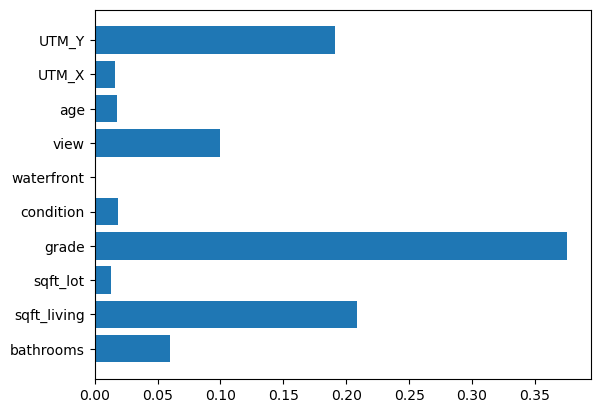

In [15]:
import matplotlib.pyplot as plt
plt.barh(automl.feature_names_in_, automl_xgb.feature_importances_)

We will be talking more in depth when touch on interpretable machine learning/XAI